In [1]:
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
#Load TF-IDF Data
X_train = joblib.load("Feature Representations/X_train_tfidf.pkl")
X_test = joblib.load("Feature Representations/X_test_tfidf.pkl")

y_train = joblib.load("Feature Representations/y_train.pkl")
y_test = joblib.load("Feature Representations/y_test.pkl")

In [4]:
#Create 3 models (compare and choose the best)
models = {

    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

}


In [5]:
#Train All Models
results = []

trained_models = {}

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    trained_models[name] = model

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted"
    )

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1

    })

    print(classification_report(y_test, prediction))

Naive Bayes
              precision    recall  f1-score   support

    Negative       0.61      0.74      0.67        76
     Neutral       0.79      0.49      0.61        75
    Positive       0.64      0.74      0.69        77

    accuracy                           0.66       228
   macro avg       0.68      0.66      0.65       228
weighted avg       0.68      0.66      0.65       228

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.61      0.66      0.63        76
     Neutral       0.72      0.61      0.66        75
    Positive       0.66      0.70      0.68        77

    accuracy                           0.66       228
   macro avg       0.66      0.66      0.66       228
weighted avg       0.66      0.66      0.66       228

SVM
              precision    recall  f1-score   support

    Negative       0.64      0.70      0.67        76
     Neutral       0.71      0.61      0.66        75
    Positive       0.70      0.73      

In [6]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-score
2,SVM,0.679825,0.682048,0.679825,0.679308
0,Naive Bayes,0.657895,0.678149,0.657895,0.653675
1,Logistic Regression,0.657895,0.662083,0.657895,0.658085
3,Random Forest,0.583333,0.581519,0.583333,0.579806


In [7]:
results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)
print("Results saved.")

Results saved.


In [8]:
os.makedirs("models", exist_ok=True)

for name, model in trained_models.items():

    filename = name.lower().replace(" ", "_")

    joblib.dump(
        model,
        f"models/{filename}.pkl"
    )

print("Models saved successfully.")

Models saved successfully.


In [9]:
best = results_df.iloc[0]

print(best)

Model             SVM
Accuracy     0.679825
Precision    0.682048
Recall       0.679825
F1-score     0.679308
Name: 2, dtype: object


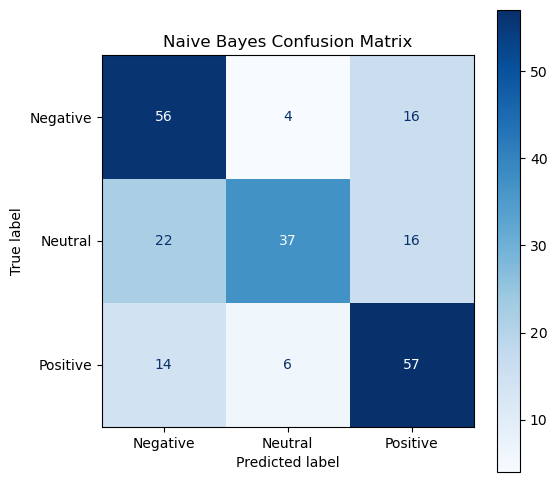

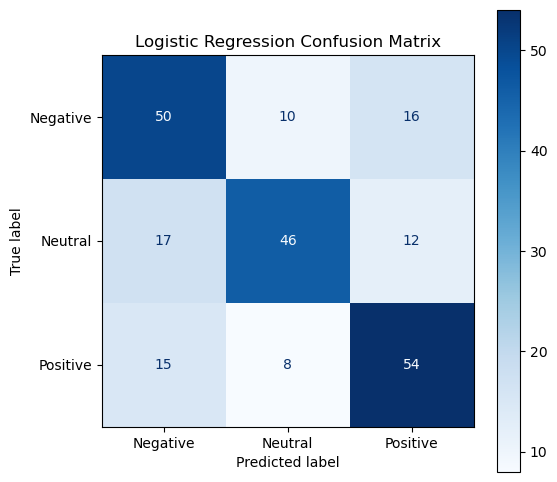

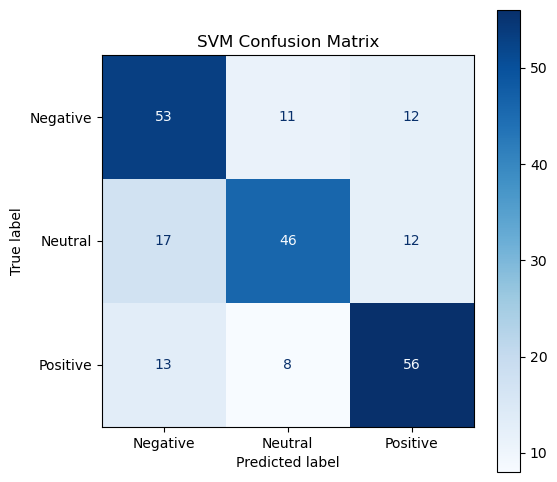

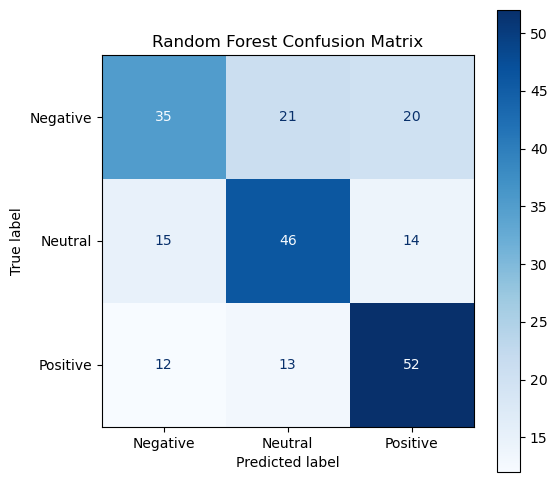

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in trained_models.items():

    prediction = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        prediction
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    fig, ax = plt.subplots(figsize=(6,6))
    
    disp.plot(ax=ax, cmap="Blues")
    
    ax.set_title(f"{name} Confusion Matrix")
    
    plt.savefig(
        f"confusion_matrices/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()
    plt.show()

In [11]:
print("="*60)
print("FINAL RESULTS")
print("="*60)

print(results_df)

FINAL RESULTS
                 Model  Accuracy  Precision    Recall  F1-score
2                  SVM  0.679825   0.682048  0.679825  0.679308
0          Naive Bayes  0.657895   0.678149  0.657895  0.653675
1  Logistic Regression  0.657895   0.662083  0.657895  0.658085
3        Random Forest  0.583333   0.581519  0.583333  0.579806


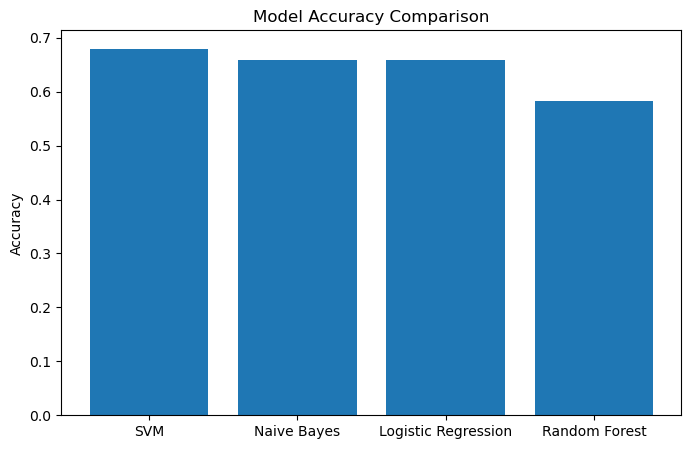

In [12]:
#Accuracy Chart
plt.figure(figsize=(8,5))
plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

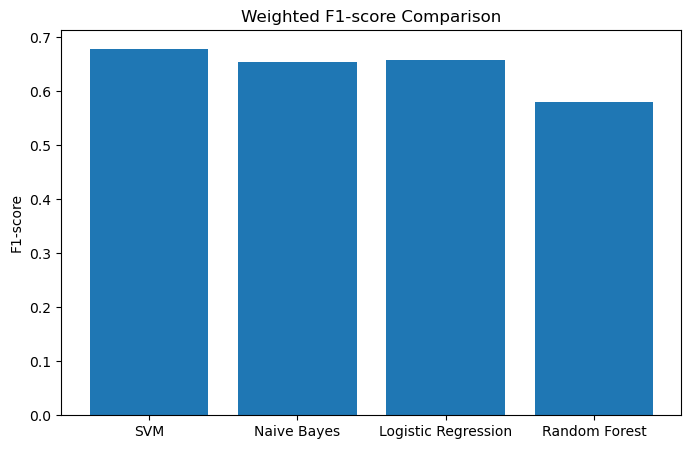

In [13]:
#F1-score Chart
plt.figure(figsize=(8,5))
plt.bar(
    results_df["Model"],
    results_df["F1-score"]
)
plt.title("Weighted F1-score Comparison")
plt.ylabel("F1-score")
plt.show()